#### Load libraries

In [3]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

import sklearn, matplotlib

print("Python:", sys.version)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("sklearn", sklearn.__version__)
print("optuna", optuna.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)

Python: 3.13.12 (main, Feb  4 2026, 09:25:39) [GCC 11.4.0]
numpy: 2.4.2
pandas: 3.0.1
sklearn 1.8.0
optuna 4.7.0
matplotlib: 3.10.8
seaborn: 0.13.2


#### Load dataset

In [4]:
df_hour = pd.read_csv("dataset/hour.csv")

#### Feature engineering

In [5]:
def agregar_features_temporales(df, col_fecha="dteday"):
    if col_fecha in df.columns:
        dt = pd.to_datetime(df[col_fecha])
    else:
        print(f"⚠️ {col_fecha} no está como columna, usando index")
        dt = pd.to_datetime(df.index)

    df["mes_sin"] = np.sin(2 * np.pi * dt.dt.month / 12)
    df["mes_cos"] = np.cos(2 * np.pi * dt.dt.month / 12)

    df["dia_semana_sin"] = np.sin(2 * np.pi * dt.dt.dayofweek / 7)
    df["dia_semana_cos"] = np.cos(2 * np.pi * dt.dt.dayofweek / 7)
    df["dia_semana"] = dt.dt.dayofweek  # 0 = Lunes, 6 = Domingo

    df["hora_sin"] = np.sin(2 * np.pi * dt.dt.hour / 24)
    df["hora_cos"] = np.cos(2 * np.pi * dt.dt.hour / 24)

    df["dia_anio_sin"] = np.sin(2 * np.pi * dt.dt.dayofyear / 365)
    df["dia_anio_cos"] = np.cos(2 * np.pi * dt.dt.dayofyear / 365)

    # Lineales — tendencia y contexto
    df["anio"] = dt.dt.year
    df["trimestre"] = dt.dt.quarter
    df["es_finde"] = (dt.dt.dayofweek >= 5).astype(int)
    df["es_festivo"] = 0  # rellenar si tienes calendario

    # Tendencia global — normalizada para no dominar
    df["tendencia"] = (dt - dt.min()).dt.days
    df["tendencia"] = (df["tendencia"] - df["tendencia"].mean()) / df["tendencia"].std()

    # Combinar features
    df["temp_hum"] = df["temp"] + df["hum"]
    df["rush_hour"] = df["hr"].apply(lambda x: 1 if x in [7, 8, 9, 17, 18, 19] else 0)
    df["is_weekend"] = df["weekday"].apply(lambda x: 1 if x in [0, 6] else 0)
    df["clima_season"] = df["weathersit"] - df["season"]
    df["temp_atemp"] = df["temp"] * df["atemp"]

    return df


df_hour = agregar_features_temporales(df_hour)

#### Drop column dteday

In [6]:
df_hour = df_hour.drop(['dteday'], axis=1)

#### Split the dataset into features/target

In [7]:
X = df_hour.drop(['cnt'], axis=1)
y = df_hour['cnt']

#### Split train/test

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Set the previously found best hyperparameters and find the last 2 best hyperparameters

In [9]:
FIXED_PARAMS = {
    "max_depth": 5,
    "min_samples_leaf": 11,
    "max_features": 0.75,
    "max_iter": 1500,
    "max_bins": 255,
    "early_stopping": True,
    "validation_fraction": 0.1,
    "n_iter_no_change": 20,
    "tol": 1e-4,
}

SEARCH_SPACE = {
    # Zona óptima confirmada para este tipo de problema
    "learning_rate": (0.004, 0.012, "log"),
    "l2_regularization": (0.05, 0.80, "log"),
}

WARM_START_POINTS = [
    {"learning_rate": 0.007, "l2_regularization": 0.50},
    {"learning_rate": 0.006, "l2_regularization": 0.09},
    {"learning_rate": 0.007, "l2_regularization": 0.18},
]

pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=2, interval_steps=1)
sampler = TPESampler(seed=42, n_startup_trials=5, warn_independent_sampling=False)

kf = KFold(n_splits=5, shuffle=True, random_state=42)


def objective(trial):
    params = {
        **FIXED_PARAMS,
        "learning_rate": trial.suggest_float(
            "learning_rate",
            *SEARCH_SPACE["learning_rate"][:2],
            log=SEARCH_SPACE["learning_rate"][2] == "log",
        ),
        "l2_regularization": trial.suggest_float(
            "l2_regularization",
            *SEARCH_SPACE["l2_regularization"][:2],
            log=SEARCH_SPACE["l2_regularization"][2] == "log",
        ),
    }

    fold_scores = []

    for fold_idx, (train_idx, valid_idx) in enumerate(kf.split(X_train, y_train)):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[valid_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[valid_idx]

        model = HistGradientBoostingRegressor(**params, random_state=42)
        model.fit(X_tr, y_tr)

        rmse_val = np.sqrt(mean_squared_error(y_val, model.predict(X_val)))
        fold_scores.append(rmse_val)

        if fold_idx >= 2:
            trial.report(float(np.mean(fold_scores)), step=fold_idx)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    return float(np.mean(fold_scores))


study = optuna.create_study(direction="minimize", pruner=pruner, sampler=sampler)
for point in WARM_START_POINTS:
    study.enqueue_trial(point)

study.optimize(objective, n_trials=50, show_progress_bar=True) 

print(f"Best params : {study.best_trial.params}")

Best trial: 49. Best value: 4.01315: 100%|██████████| 50/50 [17:58<00:00, 21.57s/it]

Best params : {'learning_rate': 0.009123253874703037, 'l2_regularization': 0.4361759436005687}


####  Perform cross-validation to evaluate the model's performance

In [10]:
best = study.best_trial.params
best_full = {
    **best,
    "max_iter": 1500,
    "max_depth": 5,
    "min_samples_leaf": 11,
    "max_features": 0.75,
    "max_bins": 255,
    "early_stopping": True,
    "validation_fraction": 0.1,
    "n_iter_no_change": 20,
    "tol": 1e-4,
    "random_state": 42,
}

scores = cross_val_score(
    HistGradientBoostingRegressor(**best_full),
    X_train,
    y_train,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
rmse = -scores

print(f"CV folds    : {rmse.round(4)}")
print(f"CV media    : {rmse.mean():.4f}")
print(f"CV std      : {rmse.std():.4f}")

CV folds    : [4.108  3.8465 4.5762 4.0009 3.5342]
CV media    : 4.0132
CV std      : 0.3416


#### Instantiate the model

In [11]:
model_final = HistGradientBoostingRegressor(**best_full)
model_final.fit(X_train, y_train)  # train completo

,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.009123253874703037
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",1500
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",5
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",11
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.4361759436005687
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",0.75
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide ` and:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_categorical.py`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for fea

#### Get predictions

In [12]:
y_pred = np.round(model_final.predict(X_test))

X_test['Actual'] = y_test
X_test['Predicted'] = y_pred.astype(int)
X_test

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,...,es_finde,es_festivo,tendencia,temp_hum,rush_hour,is_weekend,clima_season,temp_atemp,Actual,Predicted
12830,12831,3,1,6,19,0,6,0,1,0.80,...,1,0,0.822705,1.07,1,1,-2,0.557600,425,429
8688,8689,1,1,1,20,1,1,0,1,0.24,...,0,0,-0.000822,0.65,0,0,0,0.054552,88,87
7091,7092,4,0,10,2,0,5,1,1,0.32,...,0,0,-0.315000,0.98,0,0,-3,0.096960,4,4
12230,12231,2,1,5,19,0,2,1,1,0.78,...,0,0,0.703698,1.30,1,0,-1,0.555438,526,526
431,432,1,0,1,0,0,4,1,1,0.26,...,0,0,-1.652636,0.82,0,0,0,0.059098,13,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6759,6760,4,0,10,5,0,5,1,2,0.56,...,0,0,-0.381643,1.50,0,0,-2,0.296968,17,17
13989,13990,3,1,8,2,0,6,0,3,0.64,...,1,0,1.055959,1.42,0,1,0,0.378176,85,85
173,174,1,0,1,12,0,6,0,2,0.20,...,1,0,-1.709759,0.79,0,1,1,0.036360,98,96
16192,16193,4,1,11,10,1,1,0,1,0.48,...,0,0,1.498664,1.25,0,0,-3,0.225456,266,266


#### Transform test

In [13]:
X_test_arr = X_test.values if hasattr(X_test, 'values') else X_test
y_test_arr = y_test.values if hasattr(y_test, 'values') else y_test

residuos    = y_test_arr - y_pred

#### Global metrics

In [14]:
rmse = np.sqrt(mean_squared_error(y_test_arr, y_pred))
mae = mean_absolute_error(y_test_arr, y_pred)
r2 = r2_score(y_test_arr, y_pred)
mape = np.mean(np.abs(residuos / np.where(y_test_arr == 0, np.nan, y_test_arr))) * 100
bias = residuos.mean()
std_res = residuos.std()
outliers_pct = (np.abs(residuos) > 100).mean() * 100

print("=" * 50)
print("        FINAL METRICS — TEST SET")
print("=" * 50)
print(f"  RMSE              : {rmse:.4f}")
print(f"  MAE               : {mae:.4f}")
print(f"  R²                : {r2:.4f}  ({r2*100:.1f}% varianza explicada)")
print(f"  MAPE              : {mape:.2f}%")
print(f"  Bias (sesgo medio): {bias:.4f}  (ideal = 0)")
print(f"  Std residuos      : {std_res:.4f}")
print(f"  Outliers > 100    : {outliers_pct:.1f}%")
print(f"  N test            : {len(y_test_arr)}")
print("=" * 50)

        FINAL METRICS — TEST SET
  RMSE              : 3.7948
  MAE               : 1.7043
  R²                : 0.9995  (100.0% varianza explicada)
  MAPE              : 1.40%
  Bias (sesgo medio): -0.0109  (ideal = 0)
  Std residuos      : 3.7948
  Outliers > 100    : 0.0%
  N test            : 3476


#### Metrics by section

In [15]:
df_test = pd.DataFrame(
    {
        "y_real": y_test_arr,
        "y_pred": y_pred,
        "residuo": residuos,
        "abs_error": np.abs(residuos),
    }
)
df_test["tramo"] = pd.cut(
    df_test["y_real"],
    bins=[0, 100, 200, 300, 500, 9999],
    labels=["0-100", "100-200", "200-300", "300-500", ">500"],
)

resumen_tramos = (
    df_test.groupby("tramo", observed=True)
    .agg(
        n=("residuo", "count"),
        rmse=("residuo", lambda x: np.sqrt((x**2).mean())),
        mae=("abs_error", "mean"),
        sesgo_medio=("residuo", "mean"),
        pct_total=("residuo", lambda x: f"{len(x)/len(df_test)*100:.1f}%"),
    )
    .round(2)
)

print("\n=== MÉTRICAS POR TRAMO ===")
print(resumen_tramos.to_string())


=== MÉTRICAS POR TRAMO ===
            n   rmse   mae  sesgo_medio pct_total
tramo                                            
0-100    1438   0.86  0.46        -0.15     41.4%
100-200   775   1.52  1.10        -0.15     22.3%
200-300   521   2.26  1.71        -0.22     15.0%
300-500   497   4.44  2.94         0.18     14.3%
>500      245  11.91  8.42         1.34      7.0%


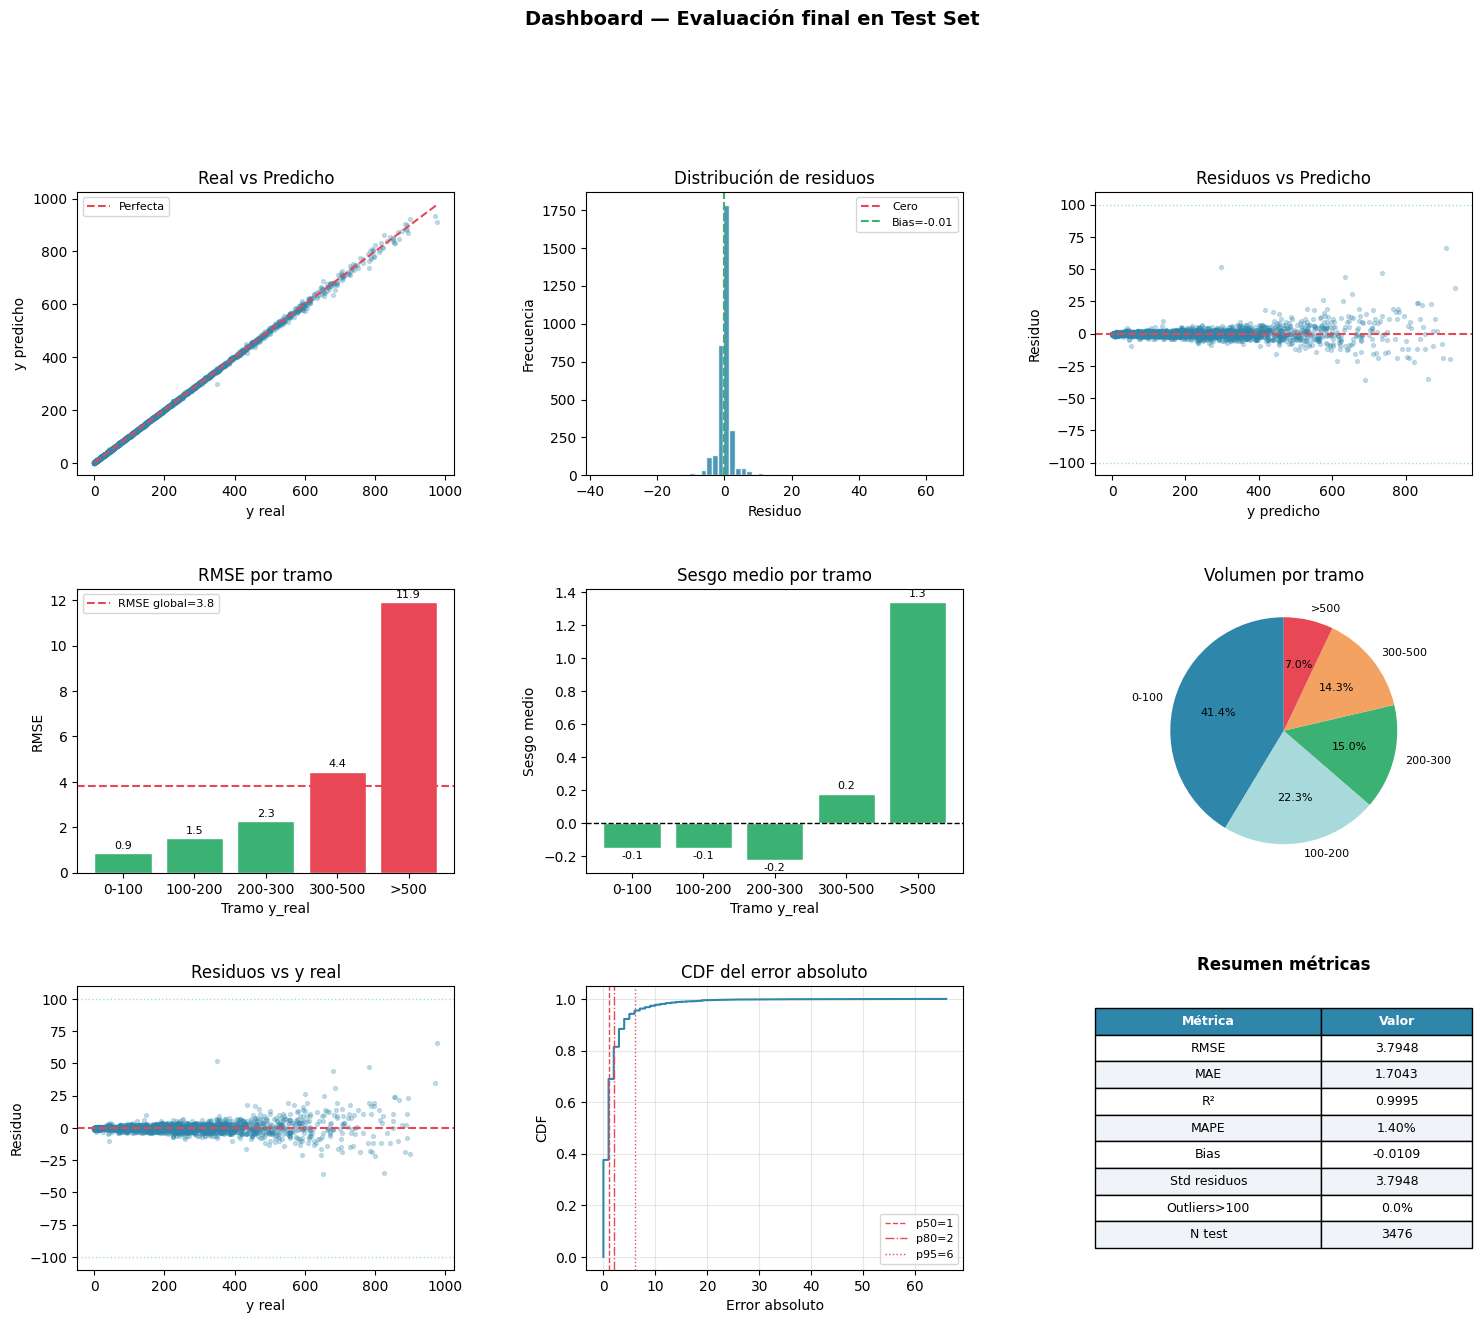

In [16]:
# Dashboard de visualizaciones
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

# Colores
C_MAIN = "#2E86AB"
C_WARN = "#E84855"
C_OK = "#3BB273"
C_LIGHT = "#A8DADC"

# Real vs Predicho
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(df_test["y_real"], df_test["y_pred"], alpha=0.25, s=8, color=C_MAIN)
lims = [df_test["y_real"].min(), df_test["y_real"].max()]
ax1.plot(lims, lims, color=C_WARN, linewidth=1.5, linestyle="--", label="Perfecta")
ax1.set_xlabel("y real")
ax1.set_ylabel("y predicho")
ax1.set_title("Real vs Predicho")
ax1.legend(fontsize=8)

# Distribución de residuos
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(residuos, bins=60, color=C_MAIN, edgecolor="white", alpha=0.85)
ax2.axvline(0, color=C_WARN, linestyle="--", linewidth=1.5, label="Cero")
ax2.axvline(bias, color=C_OK, linestyle="--", linewidth=1.5, label=f"Bias={bias:.2f}")
ax2.set_xlabel("Residuo")
ax2.set_ylabel("Frecuencia")
ax2.set_title("Distribución de residuos")
ax2.legend(fontsize=8)

# Residuos vs Predicho
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(df_test["y_pred"], residuos, alpha=0.25, s=8, color=C_MAIN)
ax3.axhline(0, color=C_WARN, linestyle="--", linewidth=1.5)
ax3.axhline(100, color=C_LIGHT, linestyle=":", linewidth=1)
ax3.axhline(-100, color=C_LIGHT, linestyle=":", linewidth=1)
ax3.set_xlabel("y predicho")
ax3.set_ylabel("Residuo")
ax3.set_title("Residuos vs Predicho")

# RMSE por tramo
ax4 = fig.add_subplot(gs[1, 0])
tramos = resumen_tramos.index.astype(str)
rmse_tramos = resumen_tramos["rmse"].values
colors_bar = [C_WARN if v > rmse else C_OK for v in rmse_tramos]
bars = ax4.bar(tramos, rmse_tramos, color=colors_bar, edgecolor="white")
ax4.axhline(
    rmse, color=C_WARN, linestyle="--", linewidth=1.5, label=f"RMSE global={rmse:.1f}"
)
ax4.bar_label(bars, fmt="%.1f", fontsize=8, padding=2)
ax4.set_xlabel("Tramo y_real")
ax4.set_ylabel("RMSE")
ax4.set_title("RMSE por tramo")
ax4.legend(fontsize=8)

# Sesgo por tramo
ax5 = fig.add_subplot(gs[1, 1])
sesgo_tramos = resumen_tramos["sesgo_medio"].values
colors_sesgo = [C_WARN if abs(v) > 10 else C_OK for v in sesgo_tramos]
bars2 = ax5.bar(tramos, sesgo_tramos, color=colors_sesgo, edgecolor="white")
ax5.axhline(0, color="black", linestyle="--", linewidth=1)
ax5.bar_label(bars2, fmt="%.1f", fontsize=8, padding=2)
ax5.set_xlabel("Tramo y_real")
ax5.set_ylabel("Sesgo medio")
ax5.set_title("Sesgo medio por tramo")

# Distribución volumen por tramo
ax6 = fig.add_subplot(gs[1, 2])
n_tramos = resumen_tramos["n"].values
ax6.pie(
    n_tramos,
    labels=tramos,
    autopct="%1.1f%%",
    colors=[C_MAIN, C_LIGHT, C_OK, "#F4A261", C_WARN],
    startangle=90,
    textprops={"fontsize": 8},
)
ax6.set_title("Volumen por tramo")

# Residuos vs y_real
ax7 = fig.add_subplot(gs[2, 0])
ax7.scatter(df_test["y_real"], residuos, alpha=0.25, s=8, color=C_MAIN)
ax7.axhline(0, color=C_WARN, linestyle="--", linewidth=1.5)
ax7.axhline(100, color=C_LIGHT, linestyle=":", linewidth=1)
ax7.axhline(-100, color=C_LIGHT, linestyle=":", linewidth=1)
ax7.set_xlabel("y real")
ax7.set_ylabel("Residuo")
ax7.set_title("Residuos vs y real")

# CDF del error absoluto
ax8 = fig.add_subplot(gs[2, 1])
abs_errors_sorted = np.sort(np.abs(residuos))
cdf = np.arange(1, len(abs_errors_sorted) + 1) / len(abs_errors_sorted)
ax8.plot(abs_errors_sorted, cdf, color=C_MAIN, linewidth=1.5)
for pct, ls in [(0.50, "--"), (0.80, "-."), (0.95, ":")]:
    val = np.percentile(np.abs(residuos), pct * 100)
    ax8.axvline(
        val, color=C_WARN, linestyle=ls, linewidth=1, label=f"p{int(pct*100)}={val:.0f}"
    )
ax8.set_xlabel("Error absoluto")
ax8.set_ylabel("CDF")
ax8.set_title("CDF del error absoluto")
ax8.legend(fontsize=8)
ax8.grid(True, alpha=0.3)

# Tabla resumen métricas
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis("off")
metricas_tabla = [
    ["Métrica", "Valor"],
    ["RMSE", f"{rmse:.4f}"],
    ["MAE", f"{mae:.4f}"],
    ["R²", f"{r2:.4f}"],
    ["MAPE", f"{mape:.2f}%"],
    ["Bias", f"{bias:.4f}"],
    ["Std residuos", f"{std_res:.4f}"],
    ["Outliers>100", f"{outliers_pct:.1f}%"],
    ["N test", f"{len(y_test_arr)}"],
]
tabla = ax9.table(
    cellText=metricas_tabla[1:],
    colLabels=metricas_tabla[0],
    cellLoc="center",
    loc="center",
    colWidths=[0.6, 0.4],
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1, 1.6)
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2E86AB")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#f0f4f8")
ax9.set_title("Resumen métricas", fontweight="bold", pad=12)

fig.suptitle(
    "Dashboard — Evaluación final en Test Set", fontsize=14, fontweight="bold", y=1.01
)
# plt.savefig("dashboard_test.png", dpi=150, bbox_inches="tight")
plt.show()

df_test["error_relativo_%"] = (
    np.abs(residuos) / np.where(y_test_arr == 0, np.nan, y_test_arr) * 100
).round(2)
df_test["abs_error"] = df_test["abs_error"].round(4)

#### Correct conversion to real units

In [17]:
# Temperatura (°C)
X_test["temp_C"] = X_test["temp"] * 41
# Humedad (%)
X_test["hum_pct"] = X_test["hum"] * 100
# Sensación térmica (°C)
X_test["atemp_C"] = X_test["atemp"] * 50
X_test["windspeed_kmh"] = (X_test["windspeed"] * 67).round()
# redondear:
X_test[["temp_C", "atemp_C", "hum_pct", "windspeed_kmh"]] = X_test[
    ["temp_C", "atemp_C", "hum_pct", "windspeed_kmh"]
].round(1)

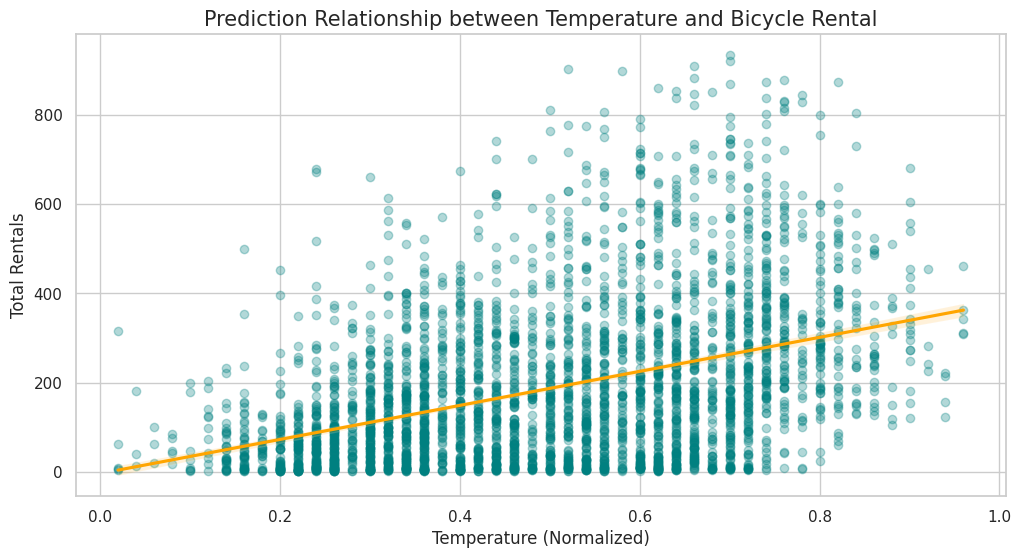

In [18]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.regplot(
    data=X_test,
    x="temp",
    y="Predicted",
    scatter_kws={"alpha": 0.3, "color": "teal"},
    line_kws={"color": "orange"},
)

plt.title("Prediction Relationship between Temperature and Bicycle Rental", fontsize=15)
plt.xlabel("Temperature (Normalized)", fontsize=12)
plt.ylabel("Total Rentals", fontsize=12)

plt.show()

#### Define the bin edges

In [19]:
# Bins de temperatura
X_test["temp_bin"] = pd.cut(
    X_test["temp_C"],
    bins=[0, 10, 20, 30, 41],
    labels=["0-10°C", "10-20°C", "20-30°C", "30-41°C"],
)

# Bins de sensación térmica
X_test["atemp_bin"] = pd.cut(
    X_test["atemp_C"],
    bins=[0, 10, 20, 30, 50],
    labels=["0-10°C", "10-20°C", "20-30°C", "30-50°C"],
)

# Bins de humedad
X_test["hum_bin"] = pd.cut(
    X_test["hum_pct"],
    bins=[0, 40, 60, 80, 100],
    labels=["0-40%", "40-60%", "60-80%", "80-100%"],
)

# Bins de Velocidad del viento
X_test["windspeed_bin"] = pd.cut(
    X_test["windspeed_kmh"], bins=[0, 10, 20, 35, 50, 70], 
    labels=[6, 17, 30, 48, 57]
)

In [20]:
orden_dias = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
mapa_dias = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}
X_test["dia_semana_str"] = X_test["dia_semana"].map(mapa_dias)

In [21]:
mapa_clima = {1: "Clear", 2: "Mist/Cloudy", 3: "Light Rain/Snow", 4: "Heavy Rain"}

X_test["clima"] = X_test["weathersit"].map(mapa_clima)

In [22]:
def plot_promedio_por_clima(df, variable, titulo, orden=None):

    datos = df.groupby(["dia_semana_str", variable])["Predicted"].mean().reset_index()

    plt.figure(figsize=(12, 7))

    sns.barplot(
        x="dia_semana_str", y="Predicted", hue=variable, data=datos, order=orden
    )

    ax = plt.gca()

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f"{height:.1f}",
                (p.get_x() + p.get_width() / 2, height),
                ha="center",
                va="bottom",
                fontsize=9,
            )

    plt.title(titulo, fontsize=15)
    plt.xlabel("Day of the week")
    plt.ylabel("Average Rent Prediction")
    plt.grid(axis="y", linestyle="--", alpha=0.6)

    plt.show()

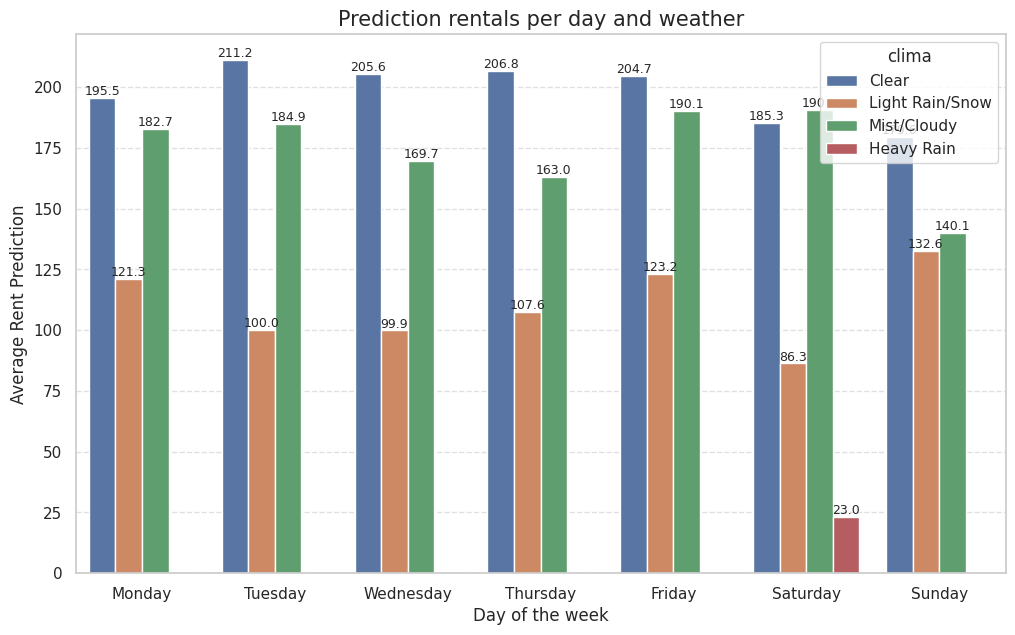

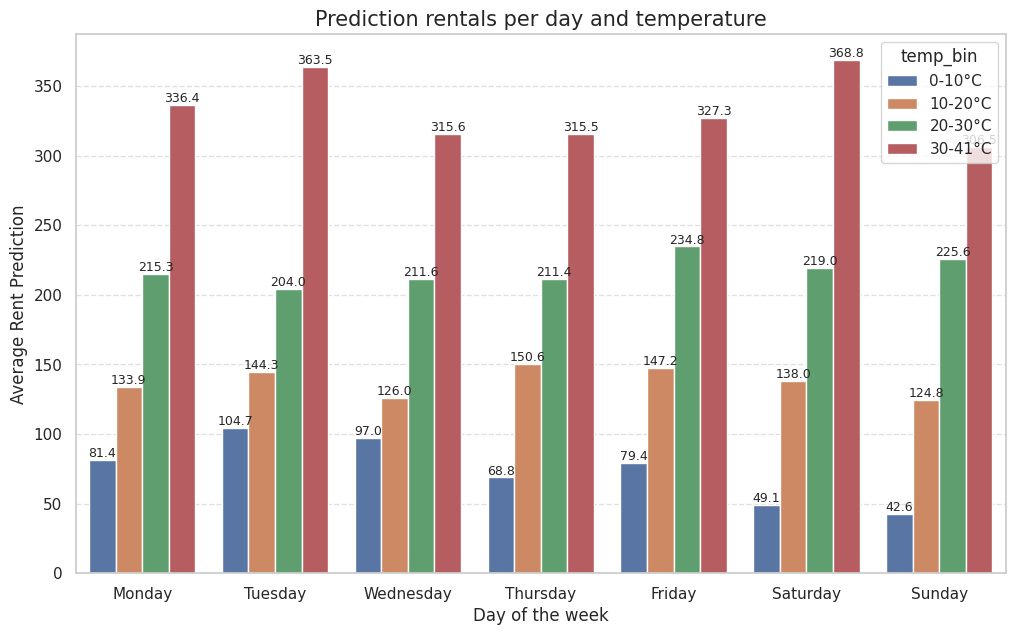

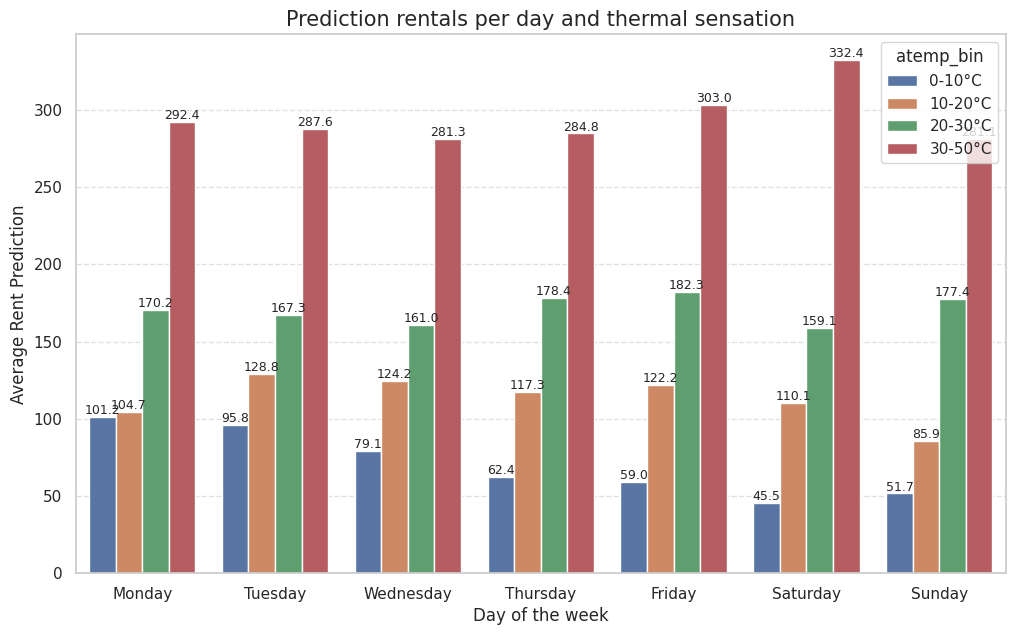

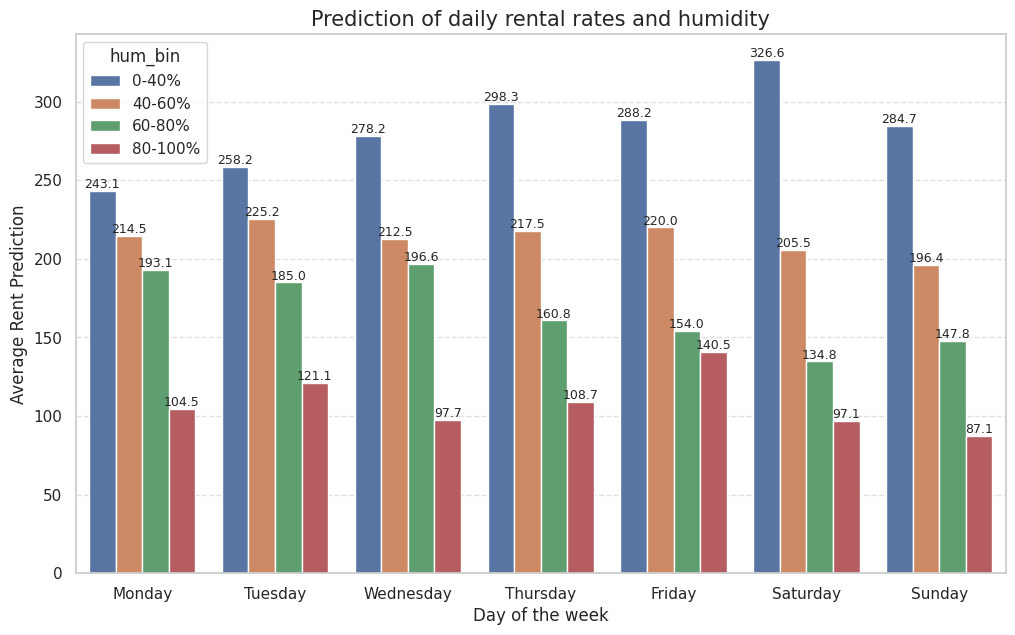

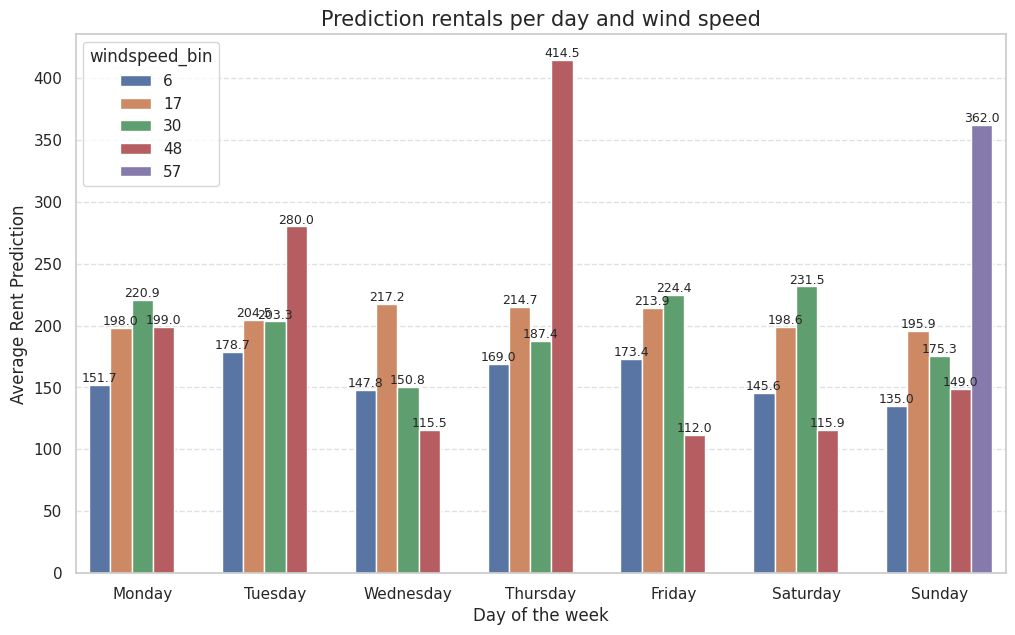

In [23]:
plot_promedio_por_clima(
    X_test, "clima", "Prediction rentals per day and weather", orden_dias
)

plot_promedio_por_clima(
    X_test, "temp_bin", "Prediction rentals per day and temperature", orden_dias
)

plot_promedio_por_clima(
    X_test,
    "atemp_bin",
    "Prediction rentals per day and thermal sensation",
    orden_dias,
)

plot_promedio_por_clima(
    X_test, "hum_bin", "Prediction of daily rental rates and humidity", orden_dias
)

plot_promedio_por_clima(
    X_test,
    "windspeed_bin",
    "Prediction rentals per day and wind speed",
    orden_dias,
)

In [24]:
def boxplots_clima(df):

    variables = [
        ("clima", "Climate type"),
        ("temp_bin", "Temperature (°C)"),
        ("atemp_bin", "Thermal sensation (°C)"),
        ("windspeed_bin", "Wind speed (km/h)"),
        ("hum_bin", "Humidity (%)"),
    ]

    for var, titulo in variables:

        plt.figure(figsize=(10, 6))

        sns.boxplot(
            data=df, x=var, y="Predicted", palette="Set2", hue=var, legend="auto"
        )

        plt.title(f"Prediction Distribution of rents by {titulo}", fontsize=14)
        plt.xlabel(titulo)
        plt.ylabel("Number of rentals")
        plt.grid(axis="y", linestyle="--", alpha=0.5)

        # plt.tight_layout()
        plt.show()

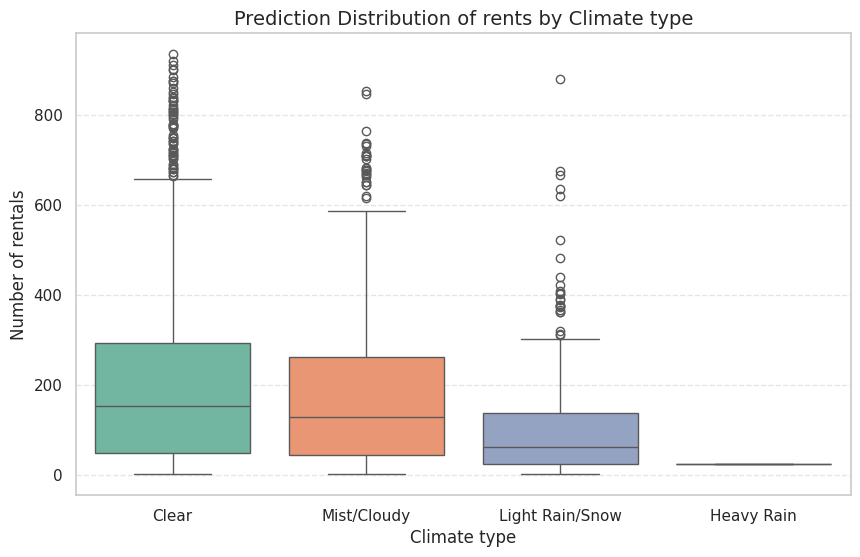

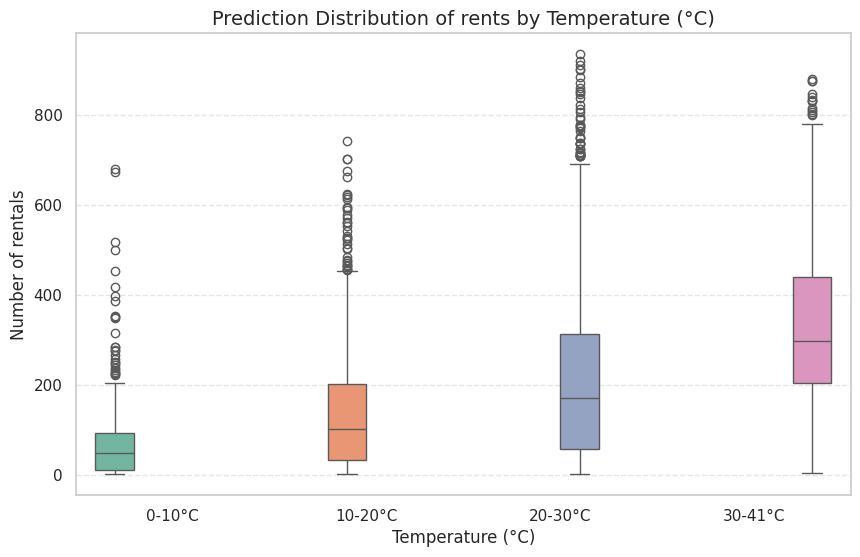

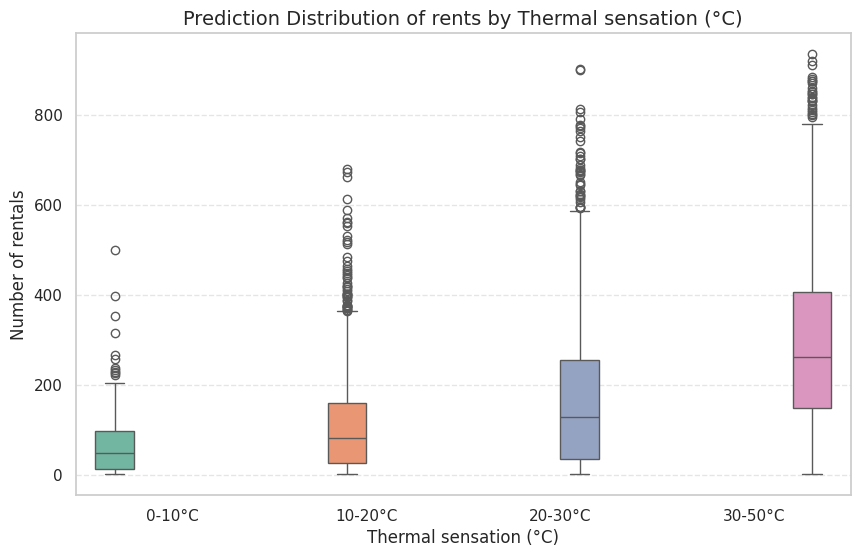

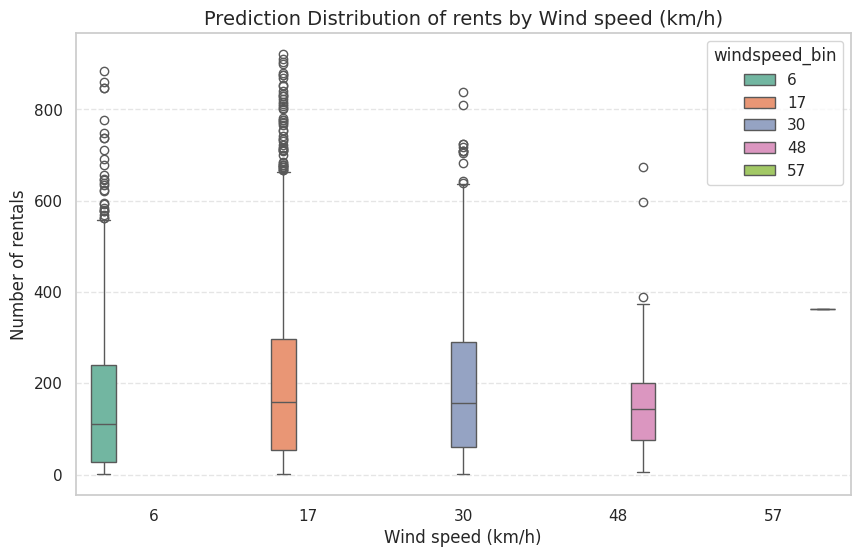

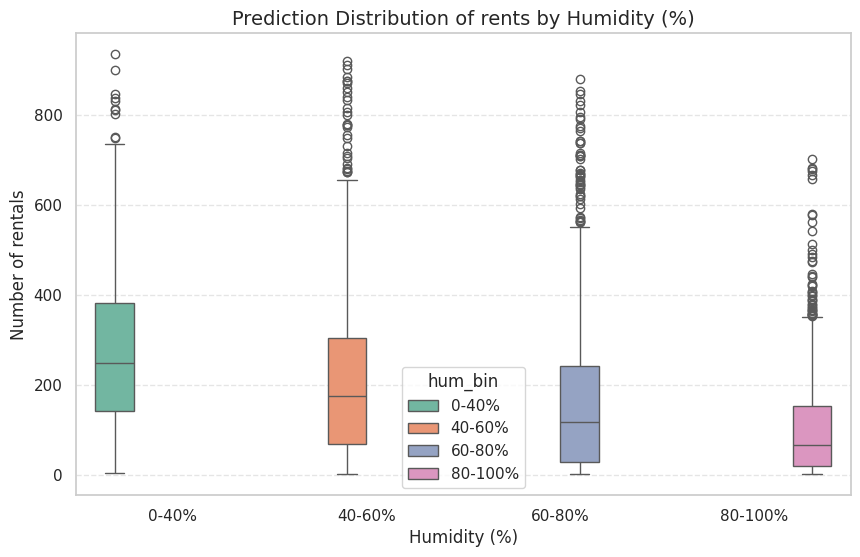

In [25]:
boxplots_clima(X_test)

In [26]:
# Repetido Crear columna día de la semana en texto si no la tienes
# mapa_dias = {0:'Monday',1:'Tuesday',2:'Wednesday',3:'Thursday',4:'Friday',5:'Saturday',6:'Sunday'}
X_test["dia_semana_str"] = X_test["dia_semana"].map(mapa_dias)

# Pivot table: filas=hora, columnas=día, valores=promedio de cnt
heatmap_data = X_test.pivot_table(
    index="hr",  # hora del día
    columns="dia_semana_str",  # día de la semana
    values="Predicted",
    aggfunc="mean",  # promedio de alquileres
)

# Ordenar columnas por semana
orden_dias = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
heatmap_data = heatmap_data[orden_dias]

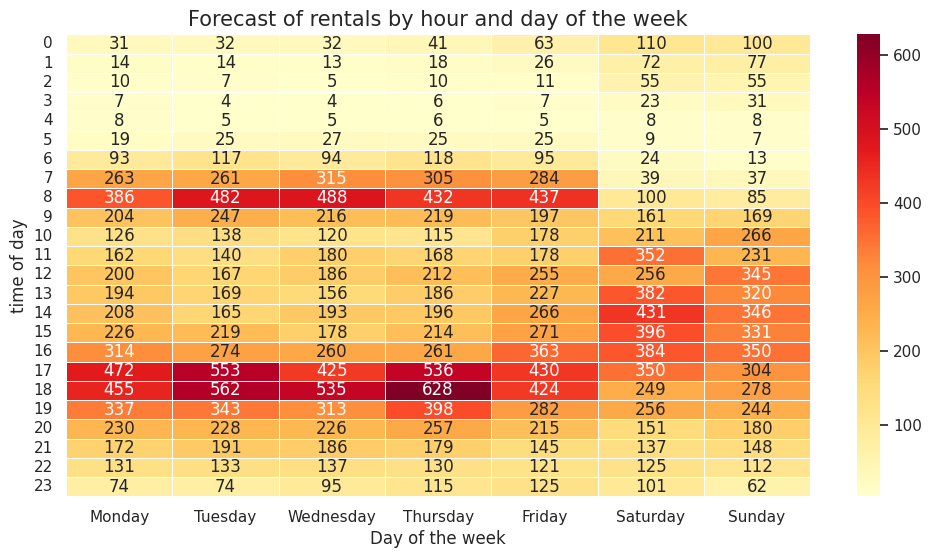

In [27]:
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=True, fmt=".0f", linewidths=0.5)

plt.title("Forecast of rentals by hour and day of the week", fontsize=15)
plt.xlabel("Day of the week")
plt.ylabel("time of day")
plt.yticks(rotation=0)
plt.show()